# Projeto 04 — Operação Nota Inflada: Fraude Educacional

Investigue os dados e responda:

1. **Existe um gap entre notas internas e notas externas (SAEB)?** Compare a nota média interna com a nota SAEB por escola. Quais escolas têm a maior discrepância?
2. **A distribuição de notas internas é "perfeita demais" em alguma escola?** Compare a variância/desvio-padrão das notas entre escolas. Há escolas com variância suspeitamente baixa?
3. **Houve salto repentino de notas em algum ano específico?** Analise a evolução temporal das notas internas — há escolas com melhora súbita incompatível com as externas?
4. **As escolas suspeitas são consistentemente as que atingem metas e recebem bonificação?** Cruze com o dataset de metas. Sempre atingem a meta, apesar do SAEB baixo?
5. **Os fatores socioeconômicos explicam o desempenho?** Escolas com alunos de renda mais alta têm notas melhores? As escolas suspeitas têm perfil socioeconômico que justifique notas tão altas?
6. **Construa a evidência visual:** Compare, lado a lado, notas internas vs. SAEB das escolas suspeitas vs. demais.

### Carregamento

In [ ]:
!pip install pandas

In [1]:
import pandas as pd

dados_desempenho = pd.read_csv('../data/projeto_04_desempenho_educacional.csv')
dados_historico_ava = pd.read_csv('../data/projeto_04_historico_avaliacoes_externas.csv')
dados_metas_bonificacao = pd.read_csv('../data/projeto_04_metas_bonificacao.csv')

In [5]:
dados_desempenho.head()

,aluno_id,ano_letivo,escola,serie,turno,idade,sexo,renda_familiar,escolaridade_pais,acesso_internet,frequencia_pct,nota_matematica,nota_portugues,nota_media_geral
0,ALU-00001,2021,Escola Alpha,6º Ano,Manhã,18,F,5+ SM,Médio Completo,1,73.9,61.1,65.1,63.1
1,ALU-00002,2021,Escola Alpha,6º Ano,Manhã,16,M,1-2 SM,Superior Completo,1,94.9,61.7,57.9,59.8
2,ALU-00003,2021,Escola Alpha,6º Ano,Manhã,17,F,1-2 SM,Fundamental Incompleto,0,80.1,63.2,56.4,59.8
3,ALU-00004,2021,Escola Alpha,6º Ano,Manhã,16,M,Até 1 SM,Fundamental Completo,1,81.2,54.1,68.9,61.5
4,ALU-00005,2021,Escola Alpha,6º Ano,Manhã,18,M,1-2 SM,Superior Completo,1,74.3,44.4,57.5,51.0


In [6]:
dados_historico_ava.head()

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct
0,2021,Escola Alpha,5º Ano,67.2,56.2,64.8,57.4,122,75.6
1,2021,Escola Alpha,9º Ano,53.8,54.0,52.5,57.3,119,83.2
2,2021,Escola Alpha,3º Médio,63.2,53.9,62.1,56.3,62,90.1
3,2021,Escola Beta,5º Ano,40.2,35.9,42.0,38.9,117,99.3
4,2021,Escola Beta,9º Ano,64.4,43.1,66.8,43.1,60,81.0


In [7]:
dados_metas_bonificacao.head()

,ano,escola,meta_nota_media,nota_media_alcancada,meta_atingida,valor_bonificacao_reais,ranking_rede
0,2021,Escola Alpha,65.1,63.4,False,0.00,12
1,2021,Escola Beta,70.2,81.1,True,36222.58,10
2,2021,Escola Gamma,62.4,56.9,False,0.00,6
3,2021,Escola Delta,63.7,74.1,True,46262.67,2
4,2021,Escola Epsilon,60.3,67.6,True,35649.98,6


In [8]:
dados_metas_bonificacao.shape[0]

48

### Explorando e tratando os datasets

In [9]:
dados_desempenho.head()

,aluno_id,ano_letivo,escola,serie,turno,idade,sexo,renda_familiar,escolaridade_pais,acesso_internet,frequencia_pct,nota_matematica,nota_portugues,nota_media_geral
0,ALU-00001,2021,Escola Alpha,6º Ano,Manhã,18,F,5+ SM,Médio Completo,1,73.9,61.1,65.1,63.1
1,ALU-00002,2021,Escola Alpha,6º Ano,Manhã,16,M,1-2 SM,Superior Completo,1,94.9,61.7,57.9,59.8
2,ALU-00003,2021,Escola Alpha,6º Ano,Manhã,17,F,1-2 SM,Fundamental Incompleto,0,80.1,63.2,56.4,59.8
3,ALU-00004,2021,Escola Alpha,6º Ano,Manhã,16,M,Até 1 SM,Fundamental Completo,1,81.2,54.1,68.9,61.5
4,ALU-00005,2021,Escola Alpha,6º Ano,Manhã,18,M,1-2 SM,Superior Completo,1,74.3,44.4,57.5,51.0


In [12]:
# Alinhando nomenclatura do campo ano entre os df
dados_desempenho.rename(columns={'ano_letivo': 'ano'}, inplace=True)

In [13]:
# Falando com professor, como no dataset original de desempenho não há 5º Ano, vamos usar o 6º Ano
dados_desempenho['serie'] = dados_desempenho['serie'].replace('6º Ano', '5º Ano')

In [14]:
# Filtro de interesse (só precisamos do 5, 9 e 3 series)
dados_desempenho = dados_desempenho[dados_desempenho['serie'].isin(['5º Ano', '9º Ano', '3º Médio'])]

# Para focar na analise de uma serie
dados_desempenho_5_ano = dados_desempenho[dados_desempenho['serie'].isin(['5º Ano'])]

In [15]:
# Há nulos?
dados_desempenho.isnull().sum()

aluno_id               0
ano                    0
escola                 0
serie                  0
turno                  0
idade                  0
sexo                   0
renda_familiar       468
escolaridade_pais    266
acesso_internet        0
frequencia_pct         0
nota_matematica        0
nota_portugues         0
nota_media_geral       0
dtype: int64

In [16]:
# Há algo duplicado?
print(dados_desempenho.duplicated().sum())  # total de linhas duplicadas

9


In [17]:
# Ver quais linhas são duplicadas
print(dados_desempenho[dados_desempenho.duplicated(keep=False)])

        aluno_id   ano          escola     serie  turno  idade sexo  \
1798   ALU-01799  2021  Escola Epsilon    5º Ano  Tarde     16    F   
8139   ALU-08140  2022      Escola Eta    5º Ano  Manhã     18    F   
8556   ALU-08557  2022    Escola Theta    5º Ano  Manhã     17    M   
8959   ALU-08960  2022    Escola Theta  3º Médio  Manhã     17    F   
9270   ALU-09271  2022     Escola Iota    9º Ano  Tarde     21    F   
18507  ALU-18508  2024  Escola Epsilon  3º Médio  Tarde     18    M   
19492  ALU-19493  2024    Escola Theta    5º Ano  Manhã     16    F   
19524  ALU-19525  2024    Escola Theta    5º Ano  Tarde     16    M   
20377  ALU-20378  2024    Escola Kappa    5º Ano  Manhã     16    F   
21725  ALU-19493  2024    Escola Theta    5º Ano  Manhã     16    F   
21726  ALU-19525  2024    Escola Theta    5º Ano  Tarde     16    M   
21729  ALU-08960  2022    Escola Theta  3º Médio  Manhã     17    F   
21732  ALU-18508  2024  Escola Epsilon  3º Médio  Tarde     18    M   
21733 

In [18]:
# Duplicatas por coluna específica (ids duplicados)
print(dados_desempenho.duplicated(subset=['aluno_id']).sum())

9


In [19]:
# Relatório completo antes de tratar
print(f"Shape original: {dados_desempenho.shape}")
print(f"Duplicatas encontradas: {dados_desempenho.duplicated().sum()}")
print(f"Linhas únicas: {dados_desempenho.shape[0] - dados_desempenho.duplicated().sum()}")

Shape original: (9291, 14)
Duplicatas encontradas: 9
Linhas únicas: 9282


In [20]:
# Removendo!
dados_desempenho = dados_desempenho.drop_duplicates().reset_index(drop=True)
print(f"Shape após limpeza: {dados_desempenho.shape}")

Shape após limpeza: (9282, 14)


### 1 - **Existe um gap entre notas internas e notas externas (SAEB)?** Compare a nota média interna com a nota SAEB por escola. Quais escolas têm a maior discrepância?

In [19]:
dados_historico_ava.head()

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct
0,2021,Escola Alpha,5º Ano,67.2,56.2,64.8,57.4,122,75.6
1,2021,Escola Alpha,9º Ano,53.8,54.0,52.5,57.3,119,83.2
2,2021,Escola Alpha,3º Médio,63.2,53.9,62.1,56.3,62,90.1
3,2021,Escola Beta,5º Ano,40.2,35.9,42.0,38.9,117,99.3
4,2021,Escola Beta,9º Ano,64.4,43.1,66.8,43.1,60,81.0


In [20]:
# Utilizando e CONFIANDO nos dados somente do dataframe dados_historico_ava (as notas diferem quando calculadas de outro dataframe)
df_gap = dados_historico_ava.copy()

df_gap["gap_matematica"] = (
    df_gap["nota_interna_media_matematica"] -
    df_gap["nota_saeb_matematica"]
)

df_gap["gap_portugues"] = (
    df_gap["nota_interna_media_portugues"] -
    df_gap["nota_saeb_portugues"]
)

df_gap["gap_medio"] = (
    df_gap["gap_matematica"] +
    df_gap["gap_portugues"]
) / 2

gap_por_escola = (
    df_gap
    .groupby("escola")[["gap_matematica", "gap_portugues", "gap_medio"]]
    .mean()
    .sort_values("gap_medio", ascending=False)
)

gap_por_escola

,gap_matematica,gap_portugues,gap_medio
escola,,,
Escola Epsilon,23.016667,22.583333,22.800000
Escola Zeta,23.908333,20.916667,22.412500
Escola Eta,22.525000,21.725000,22.125000
Escola Lambda,3.483333,4.408333,3.945833
Escola Alpha,2.591667,5.158333,3.875000
Escola Delta,4.058333,3.491667,3.775000
Escola Kappa,3.616667,2.800000,3.208333
Escola Theta,3.433333,1.883333,2.658333
Escola Beta,1.016667,4.166667,2.591667


In [ ]:
# Instalar libs de plotagem
# !pip install matplotlib
# !pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='escola'>

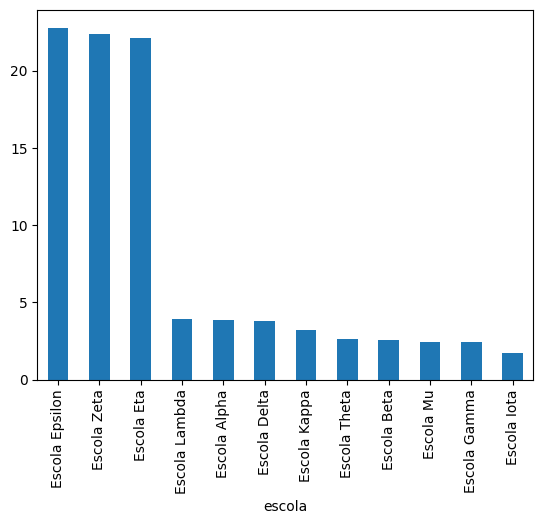

In [ ]:
# Visualizando
gap_por_escola["gap_medio"].plot(kind="bar")

### <span style="color:orange">**Análise:**</span>

- A comparação entre as notas internas e as notas do SAEB revela um padrão heterogêneo. 
- A maior parte das unidades apresenta diferenças moderadas. 

- Entretanto, três escolas, <span style="color:red">**Epsilon, Zeta e Eta**</span>, apresentam discrepâncias substancialmente maiores, com diferenças <span style="color:red">**superiores a 22 pontos**</span>. 

- Esse resultado sugere um possível <span style="color:orange">**desalinhamento**</span> entre os critérios de avaliação interna e os padrões externos.

### 2. **A distribuição de notas internas é "perfeita demais" em alguma escola?** Compare a variância/desvio-padrão das notas entre escolas. Há escolas com variância suspeitamente baixa?

In [28]:
variacao_escolas = (
    dados_desempenho
    .groupby("escola")[["nota_matematica", "nota_portugues", "nota_media_geral"]]
    .agg(["mean", "std", "var"])
)

variacao_escolas

nota_matematica                        nota_portugues  \
                          mean        std         var           mean   
escola                                                                 
Escola Alpha         58.903065  13.818704  190.956589      62.662324   
Escola Beta          58.849746  13.504244  182.364618      62.071247   
Escola Delta         59.781611  14.397333  207.283196      62.345503   
Escola Epsilon       77.675000  11.229729  126.106803      79.961828   
Escola Eta           78.292831  11.186803  125.144552      80.894932   
Escola Gamma         59.201809  13.571189  184.177177      62.425065   
Escola Iota          59.216273  14.253150  203.152285      62.059006   
Escola Kappa         59.516040  13.476072  181.604510      63.311028   
Escola Lambda        59.605867  14.293984  204.317968      62.461799   
Escola Mu            58.571189  14.728537  216.929816      61.480362   
Escola Theta         59.094595  14.190369  201.366574      62.309054   
Escola Zeta          77.842140  11.324265  128.238976      80.968824   

                                      nota_media_geral                         
                      std         var             mean        std         var  
escola                                                                         
Escola Alpha    13.115962  172.028464        60.784163  10.544757  111.191897  
Escola Beta     13.458644  181.135096        60.460814  10.829380  117.275482  
Escola Delta    12.745992  162.460306        61.064564  10.813895  116.940329  
Escola Epsilon  11.021059  121.463736        78.818817   8.950346   80.108690  
Escola Eta      11.672507  136.247412        79.592831   9.227631   85.149181  
Escola Gamma    13.248287  175.517120        60.814987  10.675133  113.958456  
Escola Iota     13.399076  179.535233        60.636273  11.000855  121.018807  
Escola Kappa    13.177845  173.655587        61.413910  10.856821  117.870559  
Escola Lambda   13.238263  175.251607        61.035202  11.102154  123.257819  
Escola Mu       13.777277  189.813353        60.026486  11.439167  130.854550  
Escola Theta    12.826079  164.508294        60.700541  10.698321  114.454073  
Escola Zeta     11.257721  126.736275        79.406737   9.214916   84.914677

In [29]:
variacao_media = (
    dados_desempenho
    .groupby("escola")["nota_media_geral"]
    .agg(["mean", "std", "var", "count"])
    .sort_values("std")
)

variacao_media

,mean,std,var,count
escola,,,,
Escola Epsilon,78.818817,8.950346,80.108690,744
Escola Zeta,79.406737,9.214916,84.914677,757
Escola Eta,79.592831,9.227631,85.149181,809
Escola Alpha,60.784163,10.544757,111.191897,783
Escola Gamma,60.814987,10.675133,113.958456,774
Escola Theta,60.700541,10.698321,114.454073,740
Escola Delta,61.064564,10.813895,116.940329,745
Escola Beta,60.460814,10.829380,117.275482,786
Escola Kappa,61.413910,10.856821,117.870559,798


In [30]:
variacao_media[variacao_media["std"] < 4]

# Aparentemente, pela comparação com as demais escolas, não foram encontrados dados que levantem alguma suspeita sobre os resultados. 
# O desvio padrão permaneceu num intervalo considerável entre 8.9 e 11,4, sendo que a quantidade de alunos avaliada é considerada suficiente.

,mean,std,var,count
escola,,,,


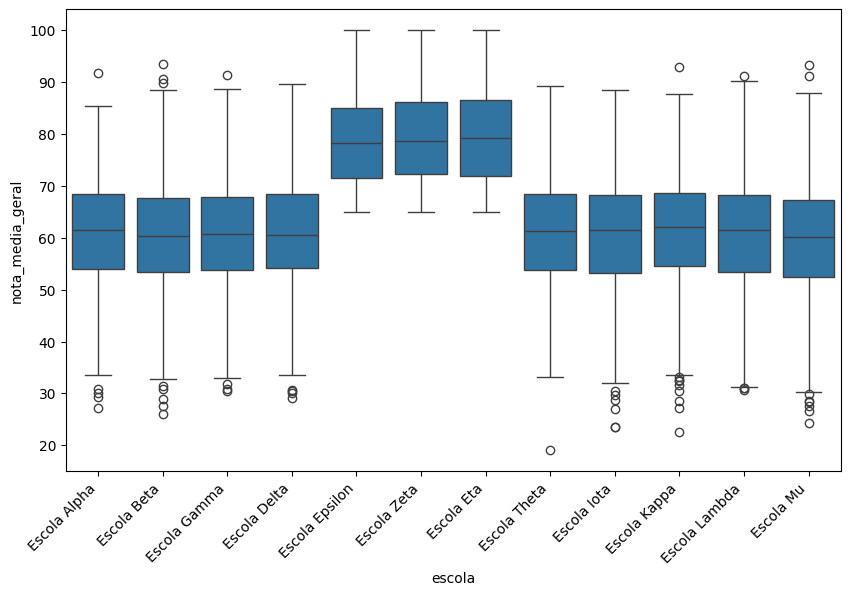

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=dados_desempenho, x="escola", y="nota_media_geral")
plt.xticks(rotation=45, ha='right')
plt.show()

# Escolas com altas médias e baixo desvio padrão são escolas que possuem qualidade do indicador e boa equidade.

### <span style="color:orange">**Análise:**</span>

- A análise da variabilidade das notas internas por escola <span style = "color:red">**não revelou**</span> distribuições artificialmente homogêneas.

- Os desvios-padrão observados variam entre <span style = "color:green">**8,9 e 11,4**</span> pontos, faixa considerada típica para avaliações educacionais.

- Assim, <span style = "color:red">**não há evidência**</span> de escolas com variância suspeitamente baixa. Entretanto, observa-se diferença expressiva nas médias das escolas, sugerindo possíveis desigualdades de desempenho ou diferenças nos critérios de avaliação interna.

### 3. **Houve salto repentino de notas em algum ano específico?** Analise a evolução temporal das notas internas — há escolas com melhora súbita incompatível com as externas?

In [35]:
dados_historico_ava.head()

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct
0,2021,Escola Alpha,5º Ano,67.2,56.2,64.8,57.4,122,75.6
1,2021,Escola Alpha,9º Ano,53.8,54.0,52.5,57.3,119,83.2
2,2021,Escola Alpha,3º Médio,63.2,53.9,62.1,56.3,62,90.1
3,2021,Escola Beta,5º Ano,40.2,35.9,42.0,38.9,117,99.3
4,2021,Escola Beta,9º Ano,64.4,43.1,66.8,43.1,60,81.0


In [36]:
# Dataframe com medias gerais, se usa a média dos valores das disciplinas
df = dados_historico_ava.copy()

df["nota_interna_media"] = (
    df["nota_interna_media_matematica"] +
    df["nota_interna_media_portugues"]
) / 2

df["nota_saeb_media"] = (
    df["nota_saeb_matematica"] +
    df["nota_saeb_portugues"]
) / 2

df.head()

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_interna_media,nota_saeb_media
0,2021,Escola Alpha,5º Ano,67.2,56.2,64.8,57.4,122,75.6,61.10,61.70
1,2021,Escola Alpha,9º Ano,53.8,54.0,52.5,57.3,119,83.2,54.90,53.90
2,2021,Escola Alpha,3º Médio,63.2,53.9,62.1,56.3,62,90.1,59.20,58.55
3,2021,Escola Beta,5º Ano,40.2,35.9,42.0,38.9,117,99.3,40.45,38.05
4,2021,Escola Beta,9º Ano,64.4,43.1,66.8,43.1,60,81.0,54.95,53.75


In [37]:
# Evolução temporal por escola
df = df.sort_values(["escola", "ano"])
df.head()

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_interna_media,nota_saeb_media
0,2021,Escola Alpha,5º Ano,67.2,56.2,64.8,57.4,122,75.6,61.1,61.70
1,2021,Escola Alpha,9º Ano,53.8,54.0,52.5,57.3,119,83.2,54.9,53.90
2,2021,Escola Alpha,3º Médio,63.2,53.9,62.1,56.3,62,90.1,59.2,58.55
36,2022,Escola Alpha,5º Ano,41.1,58.5,45.2,55.0,149,95.4,50.1,49.80
37,2022,Escola Alpha,9º Ano,43.8,85.1,50.9,91.9,78,92.7,71.4,64.45


In [38]:
# Variação por ano
df["delta_interna"] = df.groupby("escola")["nota_interna_media"].diff()
df["delta_saeb"] = df.groupby("escola")["nota_saeb_media"].diff()

df.head()

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_interna_media,nota_saeb_media,delta_interna,delta_saeb
0,2021,Escola Alpha,5º Ano,67.2,56.2,64.8,57.4,122,75.6,61.1,61.70,NaN,NaN
1,2021,Escola Alpha,9º Ano,53.8,54.0,52.5,57.3,119,83.2,54.9,53.90,-6.2,-7.80
2,2021,Escola Alpha,3º Médio,63.2,53.9,62.1,56.3,62,90.1,59.2,58.55,4.3,4.65
36,2022,Escola Alpha,5º Ano,41.1,58.5,45.2,55.0,149,95.4,50.1,49.80,-9.1,-8.75
37,2022,Escola Alpha,9º Ano,43.8,85.1,50.9,91.9,78,92.7,71.4,64.45,21.3,14.65


In [39]:
# Saltos suspeitos
saltos = df[
    (df["delta_interna"] > 10) &
    (df["delta_saeb"] < 5)
]

saltos

# Aqui nenhum caso atende simultaneamente aos dois critérios (não existe salto interno grande sem alguma mudança no SAEB.)
# Em outras palavras, nenhuma escola cresceu demais nos dados interno ao passo de cair no SAEB. 

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_interna_media,nota_saeb_media,delta_interna,delta_saeb


In [40]:
# Vendo só o salto interno
# saltos = df[df["delta_interna"] > 16]
# saltos

saltos = df[(df["delta_interna"] > 15) & (df["serie_avaliada"] == "3º Médio")]
saltos

,ano,escola,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_interna_media,nota_saeb_media,delta_interna,delta_saeb
110,2024,Escola Alpha,3º Médio,63.4,54.6,64.8,61.6,146,76.7,63.20,59.00,19.10,16.50
77,2023,Escola Beta,3º Médio,78.6,54.5,79.4,56.2,66,91.9,67.80,66.55,18.15,16.90
137,2024,Escola Kappa,3º Médio,57.0,58.0,61.4,65.0,109,94.0,63.20,57.50,18.50,20.70
23,2021,Escola Theta,3º Médio,90.2,54.9,90.6,52.9,73,75.9,71.75,72.55,29.00,37.60
89,2023,Escola Zeta,3º Médio,61.1,76.0,94.3,100.0,105,83.2,97.15,68.55,21.55,20.65


In [41]:
# Ordenando por maior salto interno
df[["escola","ano","delta_interna","delta_saeb"]].sort_values("delta_interna", ascending=False)

,escola,ano,delta_interna,delta_saeb
23,Escola Theta,2021,29.00,37.60
66,Escola Lambda,2022,28.45,37.40
90,Escola Eta,2023,27.05,17.75
45,Escola Delta,2022,22.65,26.70
89,Escola Zeta,2023,21.55,20.65
...,...,...,...,...
27,Escola Kappa,2021,NaN,NaN
30,Escola Lambda,2021,NaN,NaN
33,Escola Mu,2021,NaN,NaN
21,Escola Theta,2021,NaN,NaN


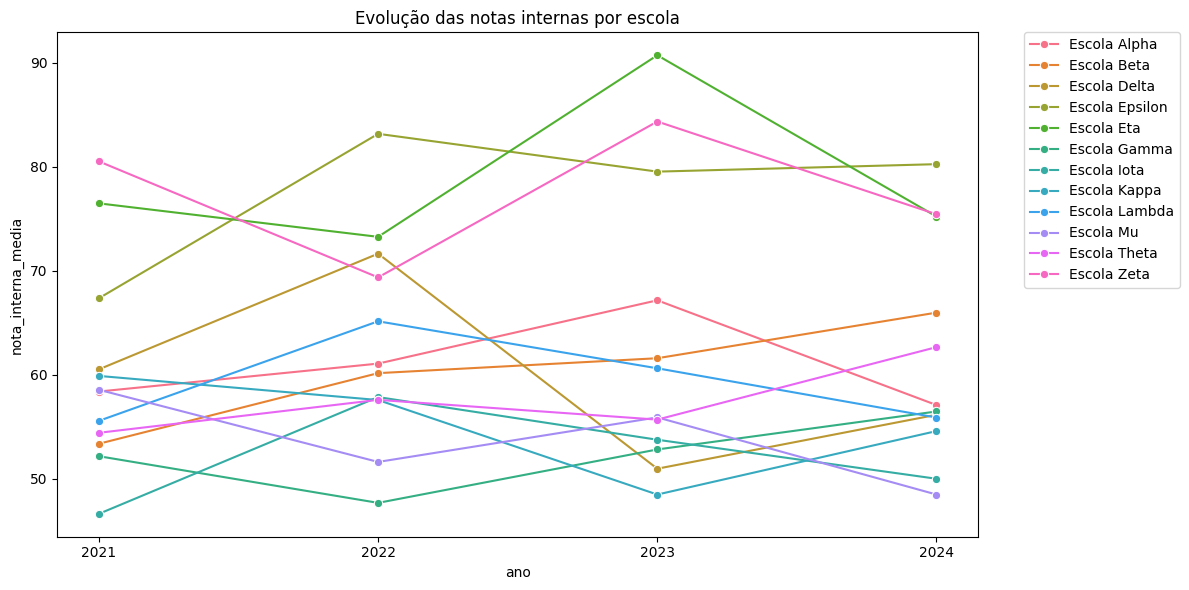

In [42]:
# Dataviz
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))  # aumenta um pouco a largura para compensar

sns.lineplot(
    data=df,
    x="ano",
    y="nota_interna_media",
    hue="escola",
    marker="o",
    errorbar=None  # remove o sombreamento
)

plt.title("Evolução das notas internas por escola")
plt.xticks(df["ano"].unique())  # só os anos que existem no dado

plt.legend(
    bbox_to_anchor=(1.05, 1),  # posição: fora à direita
    loc="upper left",          # âncora da legenda
    borderaxespad=0
)

plt.tight_layout()  # ajusta o layout para não cortar a legenda
plt.show()

### <span style="color:orange">**Análise:**</span>

- A análise da evolução temporal das notas internas revela que a maior parte das escolas apresenta variações graduais ao longo dos anos. Entretanto, algumas unidades exibem saltos abruptos de desempenho em determinados períodos.

- Destaque Crítico: As escolas <span style="color:#e74c3c">Epsilon, Zeta e Eta</span> registram aumentos <span style="color:#e74c3c">superiores a 15 pontos</span> em um único ano (2021-2022 ou 2022-2023).

- Implicação: Essas variações são incomuns em avaliações educacionais e podem indicar <span style="color:#f39c12">mudanças nos critérios de avaliação interna</span>.

- Correlação: Algumas dessas unidades já haviam apresentado discrepâncias elevadas entre notas internas e externas, reforçando a hipótese de <span style="color:#3498db">desalinhamento entre os sistemas de avaliação</span>.

### 4. **As escolas suspeitas são consistentemente as que atingem metas e recebem bonificação?** Cruze com o dataset de metas. Sempre atingem a meta, apesar do SAEB baixo?

In [43]:
dados_metas_bonificacao.head()

,ano,escola,meta_nota_media,nota_media_alcancada,meta_atingida,valor_bonificacao_reais,ranking_rede
0,2021,Escola Alpha,65.1,63.4,False,0.00,12
1,2021,Escola Beta,70.2,81.1,True,36222.58,10
2,2021,Escola Gamma,62.4,56.9,False,0.00,6
3,2021,Escola Delta,63.7,74.1,True,46262.67,2
4,2021,Escola Epsilon,60.3,67.6,True,35649.98,6


In [44]:
# Merge
df_metas = dados_metas_bonificacao.merge(
    dados_historico_ava,
    on=["ano", "escola"],
    how="left"
)
df_metas.head()

,ano,escola,meta_nota_media,nota_media_alcancada,meta_atingida,valor_bonificacao_reais,ranking_rede,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct
0,2021,Escola Alpha,65.1,63.4,False,0.00,12,5º Ano,67.2,56.2,64.8,57.4,122,75.6
1,2021,Escola Alpha,65.1,63.4,False,0.00,12,9º Ano,53.8,54.0,52.5,57.3,119,83.2
2,2021,Escola Alpha,65.1,63.4,False,0.00,12,3º Médio,63.2,53.9,62.1,56.3,62,90.1
3,2021,Escola Beta,70.2,81.1,True,36222.58,10,5º Ano,40.2,35.9,42.0,38.9,117,99.3
4,2021,Escola Beta,70.2,81.1,True,36222.58,10,9º Ano,64.4,43.1,66.8,43.1,60,81.0


In [45]:
# Criando média SAEB
df_metas["nota_saeb_media"] = (
    df_metas["nota_saeb_matematica"] +
    df_metas["nota_saeb_portugues"]
) / 2

In [46]:
df_metas

,ano,escola,meta_nota_media,nota_media_alcancada,meta_atingida,valor_bonificacao_reais,ranking_rede,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_saeb_media
0,2021,Escola Alpha,65.1,63.4,False,0.00,12,5º Ano,67.2,56.2,64.8,57.4,122,75.6,61.70
1,2021,Escola Alpha,65.1,63.4,False,0.00,12,9º Ano,53.8,54.0,52.5,57.3,119,83.2,53.90
2,2021,Escola Alpha,65.1,63.4,False,0.00,12,3º Médio,63.2,53.9,62.1,56.3,62,90.1,58.55
3,2021,Escola Beta,70.2,81.1,True,36222.58,10,5º Ano,40.2,35.9,42.0,38.9,117,99.3,38.05
4,2021,Escola Beta,70.2,81.1,True,36222.58,10,9º Ano,64.4,43.1,66.8,43.1,60,81.0,53.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,2024,Escola Lambda,69.2,77.3,True,25678.81,2,9º Ano,68.5,45.8,67.1,49.7,80,96.6,57.15
140,2024,Escola Lambda,69.2,77.3,True,25678.81,2,3º Médio,57.5,56.5,60.0,55.6,93,90.0,57.00
141,2024,Escola Mu,63.9,64.0,True,21307.37,11,5º Ano,45.2,38.7,44.2,39.6,72,82.7,41.95
142,2024,Escola Mu,63.9,64.0,True,21307.37,11,9º Ano,62.1,43.8,64.6,45.2,93,93.2,52.95


In [47]:
# Recálculo de gap
df_metas["gap"] = df_metas["nota_media_alcancada"] - df_metas["nota_saeb_media"]

In [48]:
# Suspeitas
suspeitas = ["Escola Epsilon", "Escola Zeta", "Escola Eta"]
df_suspeitas = df_metas[df_metas["escola"].isin(suspeitas)]
df_suspeitas

,ano,escola,meta_nota_media,nota_media_alcancada,meta_atingida,valor_bonificacao_reais,ranking_rede,serie_avaliada,nota_saeb_matematica,nota_saeb_portugues,nota_interna_media_matematica,nota_interna_media_portugues,numero_alunos_avaliados,taxa_participacao_pct,nota_saeb_media,gap
12,2021,Escola Epsilon,60.3,67.6,True,35649.98,6,5º Ano,46.4,39.2,69.6,62.7,143,93.0,42.80,24.80
13,2021,Escola Epsilon,60.3,67.6,True,35649.98,6,9º Ano,50.1,38.7,67.7,57.1,77,88.2,44.40,23.20
14,2021,Escola Epsilon,60.3,67.6,True,35649.98,6,3º Médio,39.9,63.1,62.1,85.0,74,91.7,51.50,16.10
15,2021,Escola Zeta,63.0,69.9,True,36746.14,3,5º Ano,63.6,60.9,87.0,76.5,104,88.8,62.25,7.65
16,2021,Escola Zeta,63.0,69.9,True,36746.14,3,9º Ano,46.1,66.6,60.6,85.0,94,92.2,56.35,13.55
17,2021,Escola Zeta,63.0,69.9,True,36746.14,3,3º Médio,67.3,62.8,89.8,84.2,103,93.3,65.05,4.85
18,2021,Escola Eta,67.0,76.0,True,29644.65,2,5º Ano,57.4,71.4,85.6,86.4,73,78.3,64.40,11.60
19,2021,Escola Eta,67.0,76.0,True,29644.65,2,9º Ano,41.1,73.0,60.6,94.6,115,88.8,57.05,18.95
20,2021,Escola Eta,67.0,76.0,True,29644.65,2,3º Médio,46.5,42.1,69.6,62.1,145,92.2,44.30,31.70
48,2022,Escola Epsilon,53.5,62.5,True,26252.51,11,5º Ano,73.7,54.1,92.5,72.9,125,92.3,63.90,-1.40


In [49]:
# Taxa de meta
df_suspeitas.groupby("escola")["meta_atingida"].mean()

# Escolas podem estar diminuindo a exigência da avaliação interna para alcançar a meta de bonificação? Forte suspeita.

escola
Escola Epsilon    1.0
Escola Eta        1.0
Escola Zeta       1.0
Name: meta_atingida, dtype: float64

In [50]:
# Ver bonificacao
df_suspeitas.groupby("escola")["valor_bonificacao_reais"].mean()

escola
Escola Epsilon    36326.625
Escola Eta        30724.795
Escola Zeta       29866.645
Name: valor_bonificacao_reais, dtype: float64

In [51]:
# Comparacao com SARB
df_metas.groupby("escola")["nota_saeb_media"].mean().sort_values()

# Não há forte discrepância em relação as demais escolas no tocante ao SAEB.

escola
Escola Gamma      49.862500
Escola Iota       50.325000
Escola Mu         51.187500
Escola Kappa      51.937500
Escola Epsilon    54.779167
Escola Theta      54.941667
Escola Zeta       55.004167
Escola Lambda     55.370833
Escola Delta      56.058333
Escola Eta        56.795833
Escola Alpha      57.062500
Escola Beta       57.691667
Name: nota_saeb_media, dtype: float64

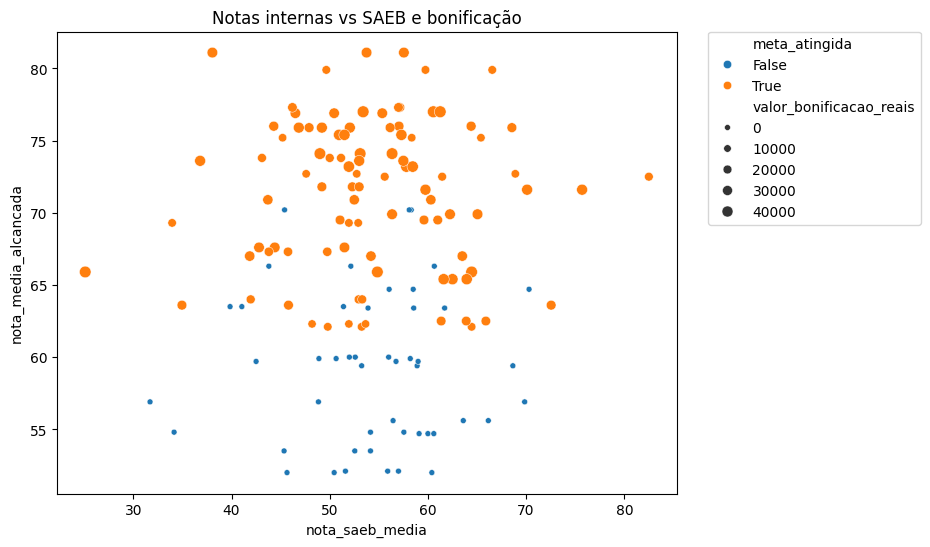

In [52]:
#Dataviz
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_metas,
    x="nota_saeb_media",
    y="nota_media_alcancada",
    hue="meta_atingida",
    size="valor_bonificacao_reais"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),  # posição: fora à direita
    loc="upper left",          # âncora da legenda
    borderaxespad=0
)

plt.title("Notas internas vs SAEB e bonificação")
plt.show()

In [53]:
# Outlier, escola com baixa media no SAEB, alta nota interna e bonificada
df_metas['nota_saeb_media'].min()

np.float64(25.1)

In [54]:
# Acha o índice da linha com menor nota_saeb_media
idx = df_metas['nota_saeb_media'].idxmin()

# Ver a linha completa
df_metas.loc[idx]

ano                                       2021
escola                           Escola Lambda
meta_nota_media                           60.6
nota_media_alcancada                      65.9
meta_atingida                             True
valor_bonificacao_reais               46762.96
ranking_rede                                12
serie_avaliada                        3º Médio
nota_saeb_matematica                      30.2
nota_saeb_portugues                       20.0
nota_interna_media_matematica             40.8
nota_interna_media_portugues              25.0
numero_alunos_avaliados                    138
taxa_participacao_pct                     81.2
nota_saeb_media                           25.1
gap                                       40.8
Name: 32, dtype: object

In [55]:
df_metas.nsmallest(10, 'nota_saeb_media')[['ano', 'escola', 'serie_avaliada', 'nota_saeb_media', 'meta_nota_media', 'nota_media_alcancada', 'meta_atingida', 'valor_bonificacao_reais']]

,ano,escola,serie_avaliada,nota_saeb_media,meta_nota_media,nota_media_alcancada,meta_atingida,valor_bonificacao_reais
32,2021,Escola Lambda,3º Médio,25.10,60.6,65.9,True,46762.96
7,2021,Escola Gamma,9º Ano,31.70,62.4,56.9,False,0.00
101,2023,Escola Kappa,3º Médio,33.95,57.3,69.3,True,17498.31
134,2024,Escola Iota,3º Médio,34.15,64.5,54.8,False,0.00
22,2021,Escola Theta,9º Ano,34.95,61.9,63.6,True,27971.56
136,2024,Escola Kappa,9º Ano,36.80,67.2,73.6,True,39047.31
3,2021,Escola Beta,5º Ano,38.05,70.2,81.1,True,36222.58
24,2021,Escola Iota,5º Ano,39.85,72.8,63.5,False,0.00
25,2021,Escola Iota,9º Ano,41.05,72.8,63.5,False,0.00
125,2024,Escola Zeta,3º Médio,41.85,58.3,67.0,True,33261.52


### <span style="color:orange">**Análise:**</span>

- O cruzamento entre os resultados de desempenho e o dataset de metas indica que algumas escolas com grande discrepância entre notas internas e externas continuam atingindo as metas institucionais e recebendo <span style="color:#2ecc71">bonificação financeira</span>.

- Ponto de Atenção: Escolas previamente identificadas com <span style="color:#e74c3c">gap elevado</span> entre avaliação interna e SAEB apresentam <span style="color:#2ecc71">altas taxas de metas atingidas</span>.

- Hipótese de Desalinhamento: Este cenário sugere que o sistema de metas pode estar baseado <span style="color:#f39c12">predominantemente em indicadores internos</span>, potencialmente desalinhados com avaliações externas padronizadas.

- Implicação: A bonificação pode estar reforçando práticas de avaliação interna que não refletem o aprendizado real mensurado por padrões nacionais.

### 5. **Os fatores socioeconômicos explicam o desempenho?** Escolas com alunos de renda mais alta têm notas melhores? As escolas suspeitas têm perfil socioeconômico que justifique notas tão altas?

In [56]:
# Gerando média da nota por escola
nota_escola = dados_desempenho.groupby("escola")["nota_media_geral"].mean()
nota_escola.head()

escola
Escola Alpha      60.784163
Escola Beta       60.460814
Escola Delta      61.064564
Escola Epsilon    78.818817
Escola Eta        79.592831
Name: nota_media_geral, dtype: float64

In [57]:
dados_desempenho["renda_familiar"].unique()

<StringArray>
['5+ SM', '1-2 SM', 'Até 1 SM', '2-3 SM', '3-5 SM', nan]
Length: 6, dtype: str

In [58]:
# Conversão de renda categórica em dado discreto (ordinal)
map_renda = {
    "Até 1 SM": 1,
    "1-2 SM": 2,
    '2-3 SM': 3,
    "3-5 SM": 4,
    "5+ SM": 5
}

dados_desempenho["renda_score"] = dados_desempenho["renda_familiar"].map(map_renda)
dados_desempenho.head()

,aluno_id,ano,escola,serie,turno,idade,sexo,renda_familiar,escolaridade_pais,acesso_internet,frequencia_pct,nota_matematica,nota_portugues,nota_media_geral,renda_score
0,ALU-00001,2021,Escola Alpha,5º Ano,Manhã,18,F,5+ SM,Médio Completo,1,73.9,61.1,65.1,63.1,5.0
1,ALU-00002,2021,Escola Alpha,5º Ano,Manhã,16,M,1-2 SM,Superior Completo,1,94.9,61.7,57.9,59.8,2.0
2,ALU-00003,2021,Escola Alpha,5º Ano,Manhã,17,F,1-2 SM,Fundamental Incompleto,0,80.1,63.2,56.4,59.8,2.0
3,ALU-00004,2021,Escola Alpha,5º Ano,Manhã,16,M,Até 1 SM,Fundamental Completo,1,81.2,54.1,68.9,61.5,1.0
4,ALU-00005,2021,Escola Alpha,5º Ano,Manhã,18,M,1-2 SM,Superior Completo,1,74.3,44.4,57.5,51.0,2.0


In [59]:
# IDE por escola
ise_escola = dados_desempenho.groupby("escola")[[
    "renda_score",
    "acesso_internet"
]].mean()

ise_escola.head()

,renda_score,acesso_internet
escola,,
Escola Alpha,2.640268,0.762452
Escola Beta,2.664430,0.758270
Escola Delta,2.660458,0.735570
Escola Epsilon,2.615714,0.743280
Escola Eta,2.647211,0.765142


In [60]:
# Merge
analise_ise = ise_escola.join(nota_escola)
analise_ise

,renda_score,acesso_internet,nota_media_geral
escola,,,
Escola Alpha,2.640268,0.762452,60.784163
Escola Beta,2.664430,0.758270,60.460814
Escola Delta,2.660458,0.735570,61.064564
Escola Epsilon,2.615714,0.743280,78.818817
Escola Eta,2.647211,0.765142,79.592831
Escola Gamma,2.610884,0.748062,60.814987
Escola Iota,2.619792,0.737888,60.636273
Escola Kappa,2.678478,0.750627,61.413910
Escola Lambda,2.656207,0.771838,61.035202


In [61]:
# Corr
analise_ise.corr()

,renda_score,acesso_internet,nota_media_geral
renda_score,1.000000,-0.258221,-0.383957
acesso_internet,-0.258221,1.000000,0.387336
nota_media_geral,-0.383957,0.387336,1.000000


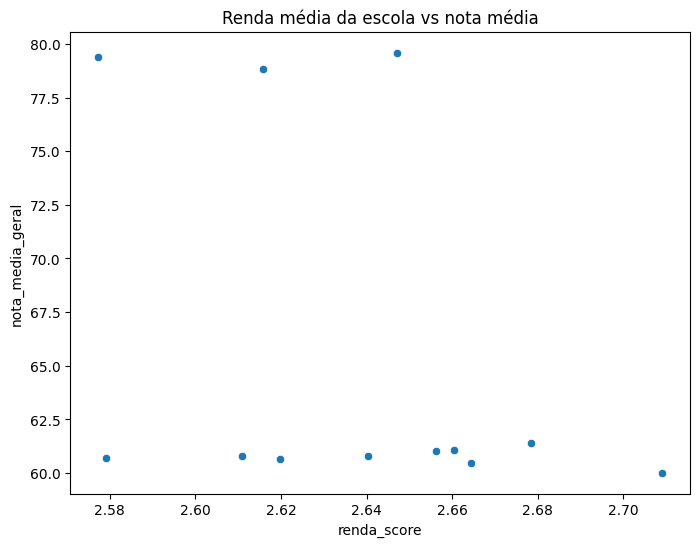

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=analise_ise,
    x="renda_score",
    y="nota_media_geral"
)

plt.title("Renda média da escola vs nota média")
plt.show()

In [63]:
# Removendo NaN
dados_desempenho.dropna(subset=['renda_score'], inplace=True)

In [64]:
from sklearn.linear_model import LinearRegression

X = dados_desempenho[["renda_score","acesso_internet"]]
y = dados_desempenho["nota_media_geral"]

modelo = LinearRegression()
modelo.fit(X,y)

dados_desempenho["nota_prevista"] = modelo.predict(X)

ModuleNotFoundError: No module named 'sklearn'

In [65]:
dados_desempenho["residuo"] = dados_desempenho["nota_media_geral"] - dados_desempenho["nota_prevista"]
dados_desempenho.groupby("escola")["residuo"].mean().sort_values()

KeyError: 'nota_prevista'

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=dados_desempenho, x="escola", y="residuo")
plt.title('Resíduos por escola')
plt.axhline(0, color="red", linestyle="--")
plt.xticks(rotation=45, ha='right')
plt.show()

ValueError: Could not interpret value `residuo` for `y`. An entry with this name does not appear in `data`.

### <span style="color:orange">**Análise:**</span>

**A análise dos fatores socioeconômicos**

A relação entre renda e desempenho acadêmico não seguiu o padrão previsto, enquanto o acesso tecnológico mostrou-se mais relevante. As correlações Identificadas foram:

- Renda Familiar: Correlação negativa ($r \approx -0,40$). Escolas com maior renda <span style="color:#e74c3c">não apresentam</span> necessariamente melhores resultados internos. 
- Acesso à Internet: Correlação positiva moderada ($r \approx 0,39$). Sugere que recursos digitais <span style="color:#3498db">contribuem diretamente</span> para o desempenho.

**Modelo de Regressão e Análise de Resíduos**

Foi estimado um modelo para prever a nota média com base no perfil socioeconômico. A diferença entre a nota real e a prevista (resíduo) revelou o seguinte: Escolas Epsilon, Zeta e Eta: 

- Apresentaram resíduos positivos altos, entre <span style="color:#e74c3c">13 e 14 pontos acima do esperado</span> pelo modelo.
- Mesmo isolando o efeito da renda e tecnologia, essas escolas registram notas internas que o modelo não consegue explicar. 

**Conclusão Final**

- Os fatores socioeconômicos não justificam o desempenho excepcional dessas unidades. Isso reforça a hipótese de que o "sucesso" observado nessas notas internas decorre de fatores institucionais ou desalinhamento avaliativo, e não de uma vantagem social dos alunos.

### 6. **Construa a evidência visual:** Compare, lado a lado, notas internas vs. SAEB das escolas suspeitas vs. demais.

In [67]:
dados_historico_ava["nota_saeb_media"] = (
    dados_historico_ava["nota_saeb_matematica"] +
    dados_historico_ava["nota_saeb_portugues"]
) / 2

In [68]:
dados_historico_ava["nota_interna_media"] = (
    dados_historico_ava["nota_interna_media_matematica"] +
    dados_historico_ava["nota_interna_media_portugues"]
) / 2

In [69]:
suspeitas = ["Escola Epsilon", "Escola Zeta", "Escola Eta"]

dados_historico_ava["grupo"] = dados_historico_ava["escola"].apply(
    lambda x: "suspeitas" if x in suspeitas else "demais"
)

In [70]:
comparacao = dados_historico_ava.groupby("grupo")[[
    "nota_interna_media",
    "nota_saeb_media"
]].mean()

comparacao

,nota_interna_media,nota_saeb_media
grupo,,
demais,56.793981,53.826389
suspeitas,77.972222,55.526389


<Axes: xlabel='grupo'>

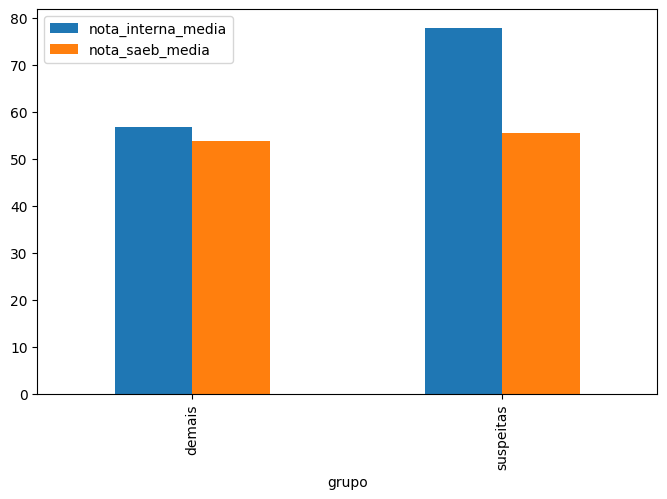

In [71]:
comparacao.plot(kind="bar", figsize=(8,5))

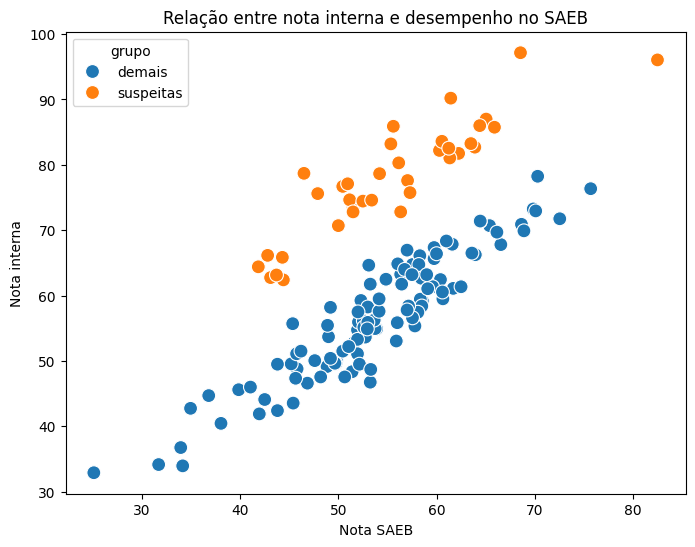

In [72]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=dados_historico_ava,
    x="nota_saeb_media",
    y="nota_interna_media",
    hue="grupo",
    s=100
)

plt.title("Relação entre nota interna e desempenho no SAEB")
plt.xlabel("Nota SAEB")
plt.ylabel("Nota interna")
plt.show()

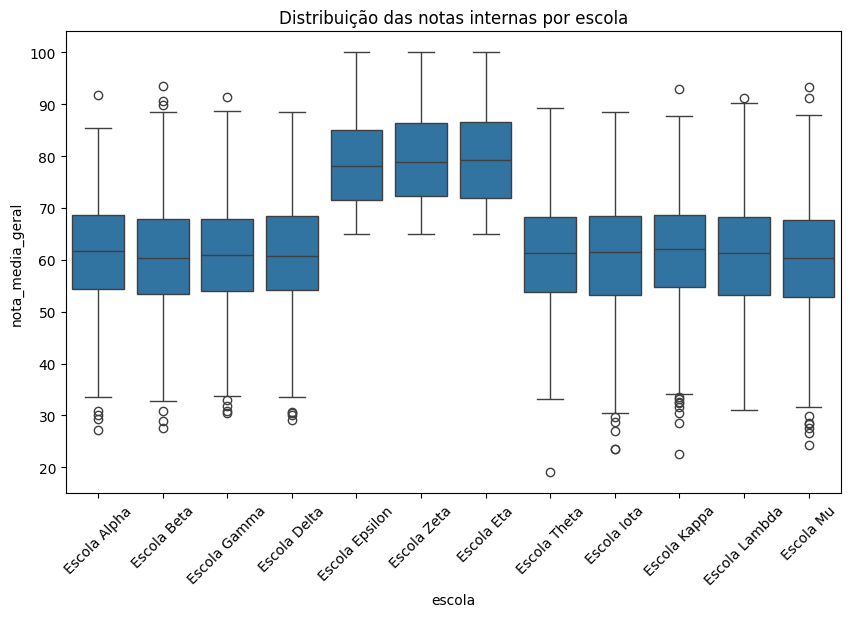

In [73]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=dados_desempenho,
    x="escola",
    y="nota_media_geral"
)

plt.xticks(rotation=45)
plt.title("Distribuição das notas internas por escola")
plt.show()

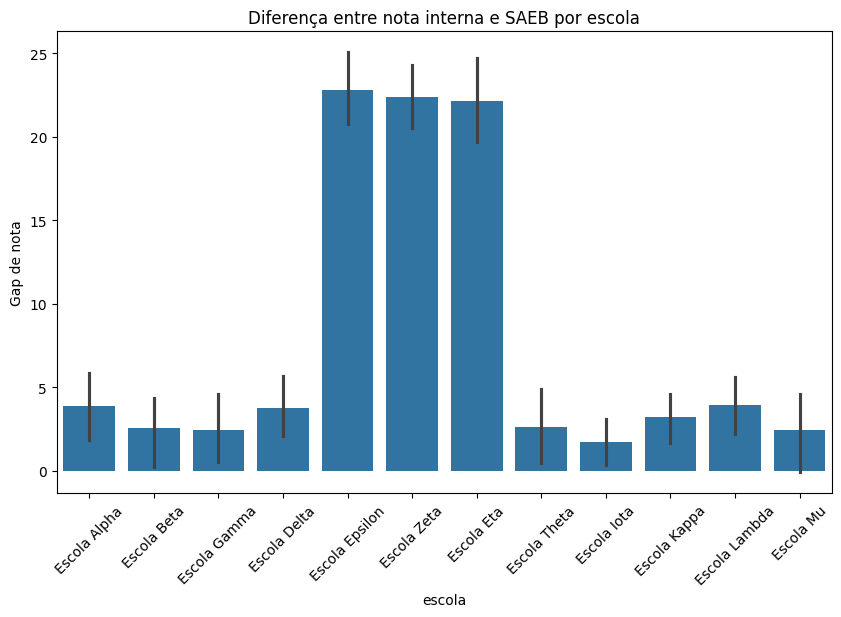

In [74]:
dados_historico_ava["gap"] = (
    dados_historico_ava["nota_interna_media"] -
    dados_historico_ava["nota_saeb_media"]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=dados_historico_ava,
    x="escola",
    y="gap"
)

plt.xticks(rotation=45)
plt.title("Diferença entre nota interna e SAEB por escola")
plt.ylabel("Gap de nota")
plt.show()


Text(0.5, 1.0, 'Linha de tendência interno vs SAEB')

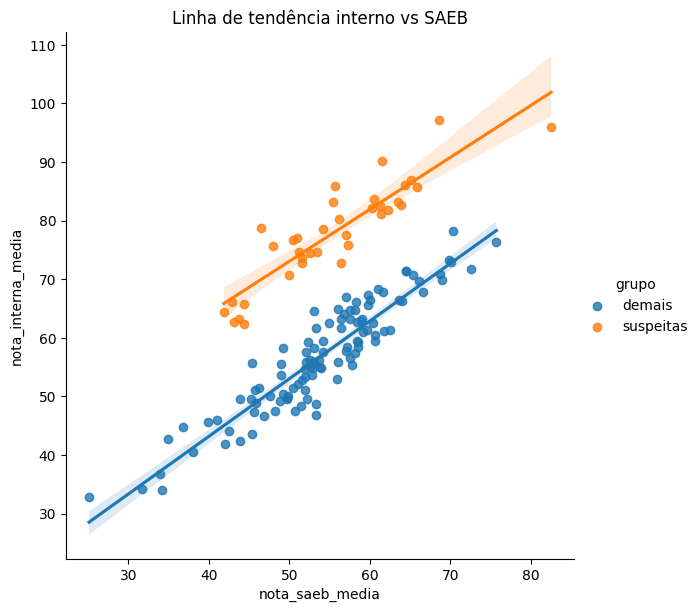

In [75]:
sns.lmplot(
    data=dados_historico_ava,
    x="nota_saeb_media",
    y="nota_interna_media",
    hue="grupo",
    height=6
)

plt.title("Linha de tendência interno vs SAEB")

### <span style="color:orange">**Análise:**</span>

**A comparação visual entre as notas internas e os resultados do SAEB revela uma diferença crítica entre os grupos de escolas, evidenciando o fenômeno da inflação de notas.**

- Grupo Suspeito (<span style="color:#e74c3c">Epsilon, Zeta e Eta</span>): Apresentam médias internas <span style="color:#e74c3c">consideravelmente mais altas</span> que o restante da rede.
- Realidade do SAEB: Apesar do "sucesso" interno, os resultados dessas mesmas escolas no SAEB permanecem <span style="color:#3498db">próximos da média geral</span>, sem o desempenho superior esperado.
- Diagnóstico: O alto desempenho interno <span style="color:#f39c12">não é refletido</span> nas avaliações externas padronizadas.

> **Conclusão: Esta discrepância reforça os indícios de que as notas internas nestas unidades estão artificialmente elevadas, sugerindo um desalinhamento pedagógico ou avaliativo profundo.**